In [14]:
%ls

All_Beauty_Reviews_By_User_Min3.json
All_Beauty_Reviews_Filtered_With_Images.jsonl
sample_data/
user_embeddings_visualization.png


In [15]:
import json
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from collections import defaultdict
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [16]:
DATASET_PATH          = "All_Beauty_Reviews_Filtered_With_Images.jsonl"
FILTERED_DATASET_PATH = "All_Beauty_Reviews_By_User_Min3.json" 
MIN_REVIEWS_PER_USER  = 3
MAX_USERS             = 100
random.seed(42)

# Load reviews
all_reviews = []
with open(DATASET_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            all_reviews.append(json.loads(line))

print(f"Total reviews loaded: {len(all_reviews)}")

# Group reviews by user id
user_reviews = defaultdict(list)
for entry in all_reviews:
    uid = entry.get("user_id") or entry.get("reviewerID") or entry.get("reviewer_id")
    if uid:
        user_reviews[uid].append(entry)

# Filter with minimum required number of reviews
qualified = {uid: revs for uid, revs in user_reviews.items()
             if len(revs) >= MIN_REVIEWS_PER_USER}

print(f"Users with >= {MIN_REVIEWS_PER_USER} reviews: {len(qualified)}")

# Same upto MAX_USERs
sampled_uids = random.sample(sorted(qualified.keys()), min(MAX_USERS, len(qualified)))

# Buid nested dict for json structure
filtered_data = {}
for uid in sampled_uids:
    revs = qualified[uid]

    # Pull out image links per review 
    structured_reviews = []
    for r in revs:
        structured_reviews.append({
            "text"      : r.get("text", "").replace("<br />", " ").strip(),
            "rating"    : r.get("rating"),
            "images"    : r.get("images", []),          # list of image URLs
            "asin"      : r.get("asin"),
            "timestamp" : r.get("timestamp") or r.get("unixReviewTime"),
            "helpful"   : r.get("helpful"),
            "verified"  : r.get("verified_purchase") or r.get("verified"),
            # keep anything else raw
            **{k: v for k, v in r.items()
               if k not in {"text","rating","images","asin",
                             "timestamp","unixReviewTime",
                             "helpful","verified_purchase","verified"}},
        })

    filtered_data[uid] = {
        "user_id"    : uid,
        "num_reviews": len(structured_reviews),
        "reviews"    : structured_reviews,
    }

print(f"Users selected: {len(filtered_data)}")
print(f"Total reviews : {sum(v['num_reviews'] for v in filtered_data.values())}")

# Save dict as JSON
with open(FILTERED_DATASET_PATH, "w") as f:
    json.dump(filtered_data, f, indent=2)

print(f"Saved → {FILTERED_DATASET_PATH}")

# Peek at one user
sample_uid  = sampled_uids[0]
sample_user = filtered_data[sample_uid]
print(f"\nSample user: {sample_uid}")
print(f"  num_reviews : {sample_user['num_reviews']}")
for i, rev in enumerate(sample_user["reviews"]):
    print(f"  Review {i+1}: rating={rev['rating']} | "
          f"images={len(rev['images'])} | "
          f"text[:60]=\"{rev['text'][:60]}…\"")

Total reviews loaded: 59684
Users with >= 3 reviews: 923
Users selected: 100
Total reviews : 566
Saved → All_Beauty_Reviews_By_User_Min3.json

Sample user: AGREQQJHG72WPM5JM3WUOMNDZEKQ
  num_reviews : 3
  Review 1: rating=4.0 | images=4 | text[:60]="This is a really great comb for getting through thick or tan…"
  Review 2: rating=5.0 | images=1 | text[:60]="This serum from a Korean skincare company is a good balance …"
  Review 3: rating=4.0 | images=3 | text[:60]="I have tried a few products by this company that I didn’t ce…"


In [17]:
import pandas as pd
import numpy as np

# ── Build a flat records list ──────────────────────────────────────────────────
records = []
for uid, user in filtered_data.items():
    ratings  = [r["rating"] for r in user["reviews"] if r["rating"] is not None]
    n_images = sum(len(r["images"]) for r in user["reviews"])
    n_text   = sum(1 for r in user["reviews"] if r.get("text"))
    verified = sum(1 for r in user["reviews"] if r.get("verified"))

    records.append({
        "user_id"      : uid,
        "num_reviews"  : user["num_reviews"],
        "mean_rating"  : round(np.mean(ratings), 2)  if ratings else None,
        "min_rating"   : min(ratings)                 if ratings else None,
        "max_rating"   : max(ratings)                 if ratings else None,
        "rating_std"   : round(np.std(ratings),  2)  if ratings else None,
        "n_with_images": n_images,
        "n_with_text"  : n_text,
        "n_verified"   : verified,
    })

df = pd.DataFrame(records).sort_values("num_reviews", ascending=False)

# ── Per-user table ─────────────────────────────────────────────────────────────
print("=" * 80)
print(f"{'USER SUMMARY':^80}")
print("=" * 80)
print(df.to_string(index=False))

# ── Aggregate stats ────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print(f"{'AGGREGATE STATS':^80}")
print("=" * 80)

agg = {
    "Total users"            : len(df),
    "Total reviews"          : df["num_reviews"].sum(),
    "Avg reviews / user"     : round(df["num_reviews"].mean(), 2),
    "Median reviews / user"  : df["num_reviews"].median(),
    "Max reviews (one user)" : df["num_reviews"].max(),
    "Min reviews (one user)" : df["num_reviews"].min(),
    "Overall mean rating"    : round(df["mean_rating"].mean(), 2),
    "Overall rating std"     : round(df["mean_rating"].std(),  2),
    "Reviews with images"    : df["n_with_images"].sum(),
    "Reviews with text"      : df["n_with_text"].sum(),
    "Verified reviews"       : df["n_verified"].sum(),
}

col_w = max(len(k) for k in agg) + 2
for k, v in agg.items():
    print(f"  {k:<{col_w}}: {v}")

# ── Rating distribution ────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print(f"{'RATING DISTRIBUTION (across all reviews)':^80}")
print("=" * 80)

all_ratings = [
    r["rating"]
    for user in filtered_data.values()
    for r in user["reviews"]
    if r["rating"] is not None
]

from collections import Counter
dist = Counter(all_ratings)
total = len(all_ratings)
for star in sorted(dist):
    pct  = dist[star] / total * 100
    bar  = "█" * int(pct / 2)
    print(f"  {star}★  {bar:<25} {dist[star]:>4} ({pct:5.1f}%)")

                                  USER SUMMARY                                  
                       user_id  num_reviews  mean_rating  min_rating  max_rating  rating_std  n_with_images  n_with_text  n_verified
  AFNCHMAKUAJOGVCKOA4XGLINHPDQ           36         4.44         2.0         5.0        0.72            141           36           0
  AHYOSWORVZFXM5QMRIAW3JTTFFIQ           26         4.38         1.0         5.0        0.92            112           26           1
  AFLI33M7ADMQ2B3DSIJLODWUHTAA           21         4.52         4.0         5.0        0.50             42           21           0
  AEAXAJACFMXIAAH4WOHRMXPSZWFA           20         4.70         3.0         5.0        0.56             36           20           1
  AEXO6YBJHQZFPLVRQJI6VX7IJDNA           15         4.73         3.0         5.0        0.68             24           15           0
  AF6RTFII4XB2EGU2C3SYBIRGG4VQ           15         4.40         2.0         5.0        0.88             26           15 

In [18]:
MODEL_NAME = "LiYuan/amazon-review-sentiment-analysis"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

print(f"Model loaded: {MODEL_NAME}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: LiYuan/amazon-review-sentiment-analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: LiYuan/amazon-review-sentiment-analysis


In [19]:
def get_review_embedding(text: str) -> np.ndarray:
    """CLS-token embedding for a single review string."""
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=256,
        padding=True
    )
    with torch.no_grad():
        outputs = model(**inputs)
    # CLS token → shape (hidden_size,)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()


def get_user_embedding(reviews: list[dict]) -> tuple[np.ndarray, list[np.ndarray]]:
    """
    Returns
    -------
    user_emb   : mean-pooled embedding across all of a user's reviews  (hidden_size,)
    review_embs: list of individual review embeddings
    """
    review_embs = []
    for entry in reviews:
        text = entry.get("text", "").replace("<br />", " ").strip()
        if text:
            review_embs.append(get_review_embedding(text))

    if not review_embs:
        dim = model.config.hidden_size
        return np.zeros(dim), []

    # Mean-pool → single user vector
    user_emb = np.mean(review_embs, axis=0)
    return user_emb, review_embs


print("Embedding functions defined.")
print("  get_review_embedding(text)  → (hidden_size,)")
print("  get_user_embedding(reviews) → (user_emb, [review_embs])")

Embedding functions defined.
  get_review_embedding(text)  → (hidden_size,)
  get_user_embedding(reviews) → (user_emb, [review_embs])


In [20]:
print("Extracting per-user embeddings (this may take several minutes)…\n")

user_ids        = []
user_embeddings = []          # one mean-pooled vector per user
all_review_embs = {}          # uid → list of review-level embeddings


for i, (uid, user_obj) in enumerate(filtered_data.items()):
    u_emb, r_embs = get_user_embedding(user_obj["reviews"])
    user_ids.append(uid)
    user_embeddings.append(u_emb)
    all_review_embs[uid] = r_embs

    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/{len(filtered_data)} users…")

user_embeddings = np.array(user_embeddings)   # (n_users, hidden_size)
print(f"\nDone. User-embedding matrix shape: {user_embeddings.shape}")

# Check: review-level embeddings for user[0]
spot_uid    = user_ids[0]
spot_revs   = all_review_embs[spot_uid]
spot_user   = filtered_data[spot_uid]              # full user object (dict)
spot_reviews = spot_user["reviews"]                # list of review dicts

print(f"\nSpot-check — user: {spot_uid}")
print(f"  Number of reviews        : {spot_user['num_reviews']}")
print(f"  Review embeddings        : {len(spot_revs)} vectors, each shape {spot_revs[0].shape}")
print(f"  User (mean) emb shape    : {user_embeddings[user_ids.index(spot_uid)].shape}")

for j, (meta, emb) in enumerate(zip(spot_reviews, spot_revs)):
    txt_preview = meta.get("text", "")[:60].replace("\n", " ")
    imgs        = meta.get("images", [])
    print(f"  Review {j+1}: rating={meta.get('rating')} | "
          f"images={len(imgs)} | \"{txt_preview}…\"")

Extracting per-user embeddings (this may take several minutes)…

  Processed 10/100 users…
  Processed 20/100 users…
  Processed 30/100 users…
  Processed 40/100 users…
  Processed 50/100 users…
  Processed 60/100 users…
  Processed 70/100 users…
  Processed 80/100 users…
  Processed 90/100 users…
  Processed 100/100 users…

Done. User-embedding matrix shape: (100, 768)

Spot-check — user: AGREQQJHG72WPM5JM3WUOMNDZEKQ
  Number of reviews        : 3
  Review embeddings        : 3 vectors, each shape (768,)
  User (mean) emb shape    : (768,)
  Review 1: rating=4.0 | images=4 | "This is a really great comb for getting through thick or tan…"
  Review 2: rating=5.0 | images=1 | "This serum from a Korean skincare company is a good balance …"
  Review 3: rating=4.0 | images=3 | "I have tried a few products by this company that I didn’t ce…"


In [21]:
perplexity = min(15, len(user_ids) - 1)   # t-SNE needs perplexity < n_samples

pca_2d  = PCA(n_components=2).fit_transform(user_embeddings)
tsne_2d = TSNE(
    n_components=2, perplexity=perplexity,
    random_state=42, n_iter=1000
).fit_transform(user_embeddings)

print(f"PCA  output shape : {pca_2d.shape}")
print(f"t-SNE output shape: {tsne_2d.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


PCA  output shape : (100, 2)
t-SNE output shape: (100, 2)


In [22]:
cos_sim = cosine_similarity(user_embeddings)   # (n_users, n_users)

# Flatten upper-triangle (exclude diagonal)
n = len(user_ids)
upper_idx = np.triu_indices(n, k=1)
sim_vals  = cos_sim[upper_idx]

# Threshold: top-10 % → "similar", bottom-10 % → "dissimilar"
high_thr = np.percentile(sim_vals, 90)
low_thr  = np.percentile(sim_vals, 10)

similar_pairs    = [(upper_idx[0][k], upper_idx[1][k])
                    for k in range(len(sim_vals)) if sim_vals[k] >= high_thr]
dissimilar_pairs = [(upper_idx[0][k], upper_idx[1][k])
                    for k in range(len(sim_vals)) if sim_vals[k] <= low_thr]

print(f"Cosine similarity — min: {sim_vals.min():.3f} | "
      f"mean: {sim_vals.mean():.3f} | max: {sim_vals.max():.3f}")
print(f"High-similarity  threshold (≥ p90): {high_thr:.3f}  → {len(similar_pairs)} pairs")
print(f"Low-similarity   threshold (≤ p10): {low_thr:.3f}  → {len(dissimilar_pairs)} pairs")

Cosine similarity — min: -0.051 | mean: 0.777 | max: 0.992
High-similarity  threshold (≥ p90): 0.961  → 495 pairs
Low-similarity   threshold (≤ p10): 0.397  → 495 pairs


/tmp/ipykernel_1345/4150503241.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


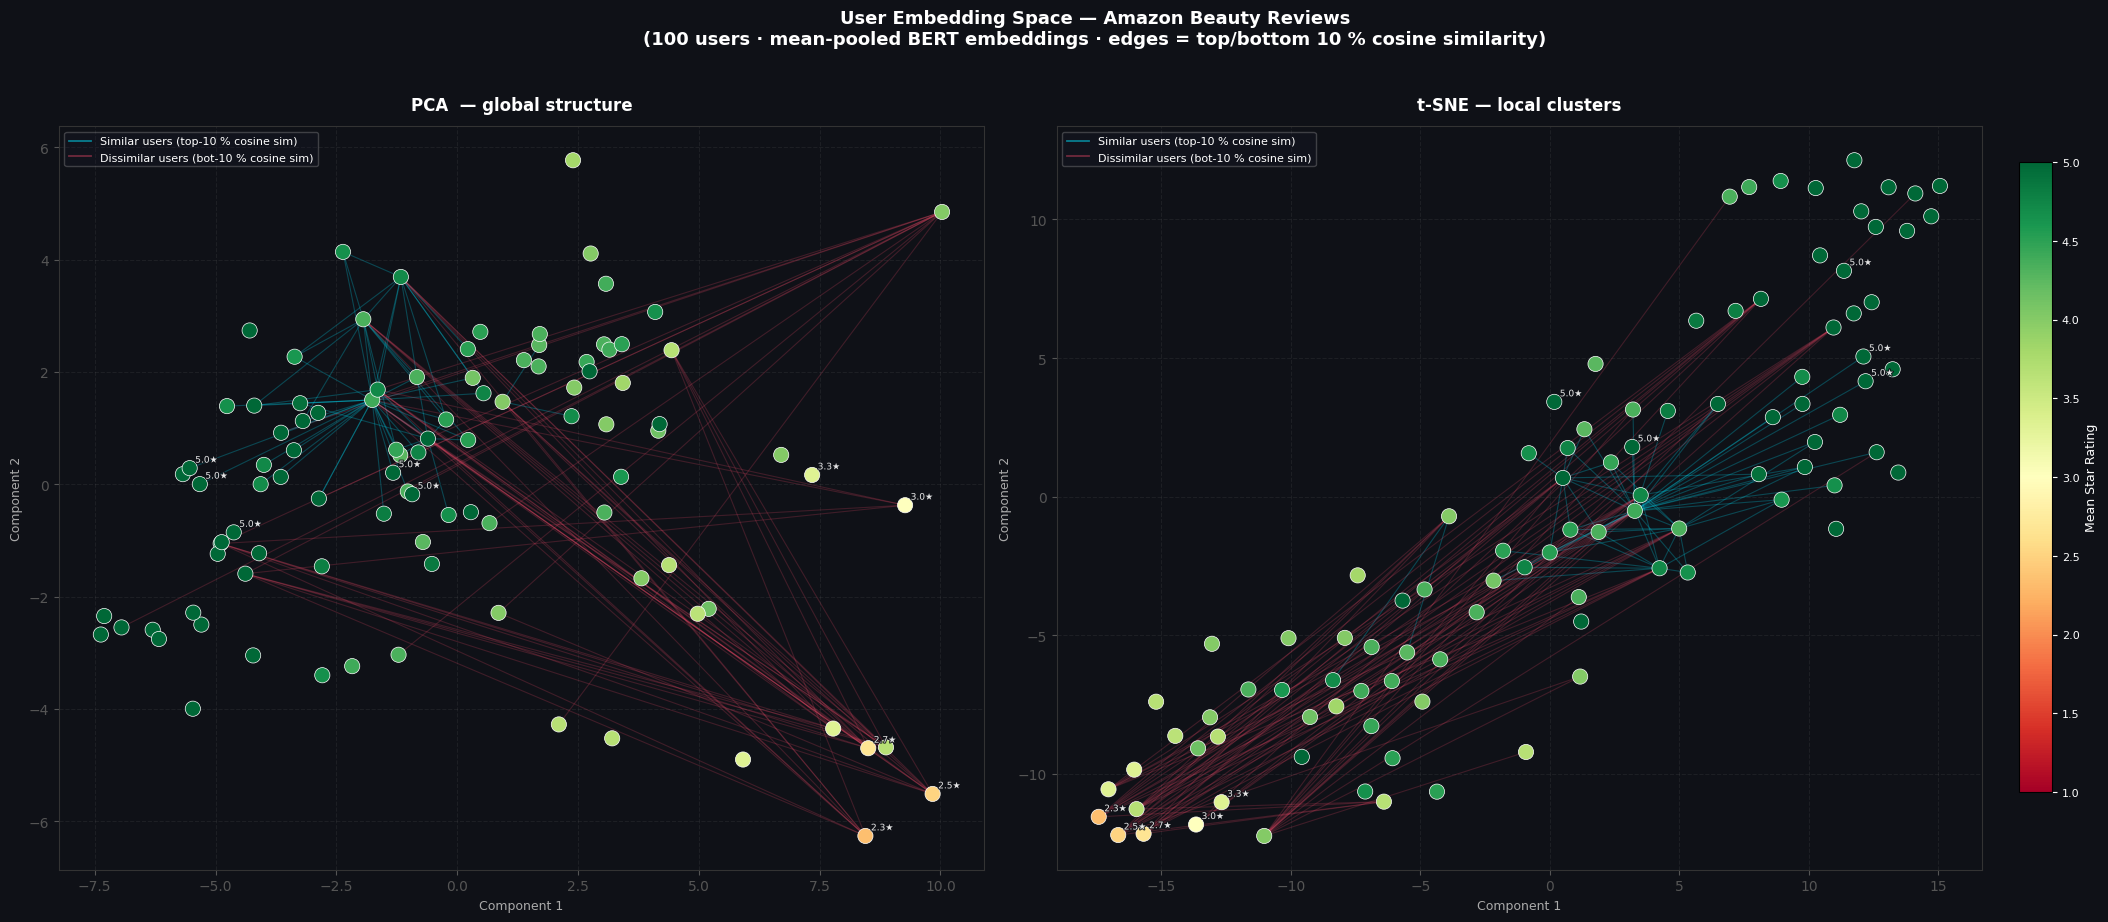

Saved → user_embeddings_visualization.png


In [23]:
# Colour every user by their mean star-rating 
mean_ratings = []
for uid in user_ids:
    ratings = [float(r.get("rating", 3)) for r in filtered_data[uid]["reviews"]]
    mean_ratings.append(np.mean(ratings))
mean_ratings = np.array(mean_ratings)

# Helper: draw edge lines between pairs 
def draw_edges(ax, coords, pairs, color, alpha, lw, label, max_edges=60):
    drawn = 0
    for i, j in pairs:
        if drawn >= max_edges:
            break
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            color=color, alpha=alpha, linewidth=lw, zorder=1,
        )
        drawn += 1
    # draw legend
    ax.plot([], [], color=color, alpha=min(alpha * 2, 1.0),
            linewidth=lw + 0.5, label=label)


# Main figure 
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#0f1117")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

cmap = plt.cm.RdYlGn

for ax, coords, title in [
    (axes[0], pca_2d,  "PCA  — global structure"),
    (axes[1], tsne_2d, "t-SNE — local clusters"),
]:
    # Draw similar / dissimilar edges 
    draw_edges(ax, coords, similar_pairs,    "#00e5ff", 0.25, 0.8,
               "Similar users (top-10 % cosine sim)")
    draw_edges(ax, coords, dissimilar_pairs, "#ff4d6d", 0.20, 0.8,
               "Dissimilar users (bot-10 % cosine sim)")

    # Scatter users, coloured by mean rating 
    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=mean_ratings, cmap=cmap, vmin=1, vmax=5,
        s=120, edgecolors="#ffffff", linewidths=0.5, zorder=4,
    )

    # Label a few extreme users
    top5    = np.argsort(mean_ratings)[-5:]
    bottom5 = np.argsort(mean_ratings)[:5]
    for idx in np.concatenate([top5, bottom5]):
        ax.annotate( 
            f"{mean_ratings[idx]:.1f}★",
            xy=(coords[idx, 0], coords[idx, 1]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6.5, color="white", alpha=0.85,
            path_effects=[pe.withStroke(linewidth=1.5, foreground="#0f1117")],
            zorder=5,
        )

    ax.set_title(title, fontsize=12, fontweight="bold",
                 color="white", pad=12)
    ax.set_xlabel("Component 1", fontsize=9, color="#aaa")
    ax.set_ylabel("Component 2", fontsize=9, color="#aaa")
    ax.tick_params(colors="#555")
    ax.grid(True, linestyle="--", alpha=0.12, color="#888")

    legend = ax.legend(fontsize=8, framealpha=0.25, loc="upper left",
                       labelcolor="white", facecolor="#1a1a2e")
    for text in legend.get_texts():
        text.set_color("white")

# Shared colour-bar 
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cb = fig.colorbar(sc, cax=cbar_ax, cmap=cmap)
cb.set_label("Mean Star Rating", color="white", fontsize=9)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "User Embedding Space — Amazon Beauty Reviews\n"
    f"({len(user_ids)} users · mean-pooled BERT embeddings · edges = top/bottom 10 % cosine similarity)",
    fontsize=13, fontweight="bold", color="white", y=1.02,
)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig("user_embeddings_visualization.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → user_embeddings_visualization.png")